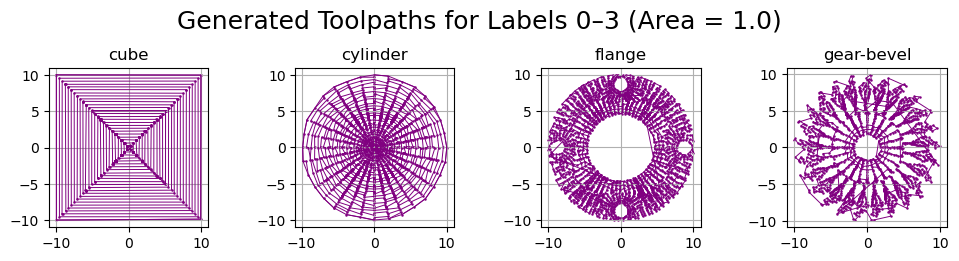

In [13]:
# =====================================================
# FIXED FULL CODE (ENC + DEC RESTORED)
# Grid Layout:
#   Columns = Selected Shape Classes
#   Rows    = Area Values
# =====================================================

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
from scipy.spatial import ConvexHull, distance

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# =====================================================
# Paths
# =====================================================
gan_model_path = Path(r"F:\JupyterWork\Testing GAN\CGAN V2 for AMF\\ModelGANV1_WGANGP_Gauss\wgangp_gauss_generator_final.pt")
ae_model_path  = Path(r"F:\JupyterWork\Testing GAN\CGAN V2 for AMF\ModelAEV4\cae_fold3.pt")

# >>> ADDED: G-code output folder (edit if you want)
gcode_output_dir = Path(r"F:\JupyterWork\Testing GAN\CGAN V2 for AMF\OutputGcode")

# =====================================================
# Hyperparameters
# =====================================================
latent_size = 512
point_size = 2900
num_classes = 10
cond_dim = 1 + num_classes
device = "cuda" if torch.cuda.is_available() else "cpu"

# =====================================================
# Class Names
# =====================================================
class_names = {
    0: "cube", 1: "cylinder", 2: "flange", 3: "gear-bevel",
    4: "gear-spur", 5: "lead-screw", 6: "nut",
    7: "propeller", 8: "pyramid", 9: "sphere",
}

# =====================================================
# Selected Labels ONLY
# =====================================================
selected_labels = [0, 1, 2, 3]

# =====================================================
# MODELS (ENC + DEC EXACT MATCH)
# =====================================================
class PointCloudCAE(nn.Module):
    def __init__(self, point_size, latent_size, cond_dim):
        super().__init__()
        self.P = point_size
        self.enc = nn.Sequential(
            nn.Linear(point_size * 2, 1024), nn.ReLU(),
            nn.Linear(1024, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, latent_size),
        )
        self.dec = nn.Sequential(
            nn.Linear(latent_size + cond_dim, 256), nn.ReLU(),
            nn.Linear(256, 512), nn.ReLU(),
            nn.Linear(512, 1024), nn.ReLU(),
            nn.Linear(1024, point_size * 2),
        )

    def forward(self, z, cond):
        return self.dec(torch.cat([z, cond], dim=1)).view(-1, self.P, 2)


class Generator(nn.Module):
    def __init__(self, latent_dim, cond_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim + cond_dim, 512),
            nn.BatchNorm1d(512), nn.LeakyReLU(0.2),
            nn.Linear(512, 512),
            nn.BatchNorm1d(512), nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024), nn.LeakyReLU(0.2),
            nn.Linear(1024, 2048),
            nn.BatchNorm1d(2048), nn.LeakyReLU(0.2),
            nn.Linear(2048, latent_dim)
        )

    def forward(self, z, cond):
        return self.model(torch.cat([z, cond], dim=1))

# =====================================================
# LOAD MODELS
# =====================================================
cae = PointCloudCAE(point_size, latent_size, cond_dim).to(device)
cae.load_state_dict(torch.load(ae_model_path, map_location=device))
cae.eval()

G = Generator(latent_size, cond_dim).to(device)
G.load_state_dict(torch.load(gan_model_path, map_location=device))
G.eval()

# =====================================================
# GEOMETRY UTILITIES (UNCHANGED)
# =====================================================
def multilayer_bands_origin(points, band_width=0.05, max_layers=3):
    d = np.linalg.norm(points, axis=1)
    r0 = d.min()
    loops, band_idx = [], set()

    for k in range(max_layers):
        mask = (d >= r0 + k * band_width) & (d <= r0 + (k + 1) * band_width)
        pts = points[mask]

        if len(pts) > 3:
            ang = np.arctan2(pts[:, 1], pts[:, 0])
            order = np.argsort(ang)
            loops.append(np.vstack([pts[order], pts[order][0]]))
            band_idx.update(np.where(mask)[0])

    return loops, points, band_idx, r0


def nested_loops_with_hull(points, band_idx, r_band, step=0.05):
    d = np.linalg.norm(points, axis=1)
    mask = np.ones(len(points), bool)
    mask[list(band_idx)] = False

    pts, d = points[mask], d[mask]
    layers = []

    if len(pts) > 3:
        try:
            hull = ConvexHull(pts)
            h = pts[hull.vertices]
            layers.append(np.vstack([h, h[0]]))
        except:
            pass

    r = d.max()

    while r > r_band:
        shell = pts[(d <= r) & (d > r - step)]

        if len(shell) > 3:
            ang = np.arctan2(shell[:, 1], shell[:, 0])
            order = np.argsort(ang)
            layers.append(np.vstack([shell[order], shell[order][0]]))

        r -= step

    return layers


def nearest_neighbor_path(points):
    idx = list(range(len(points)))
    path = [idx.pop(0)]
    while idx:
        last = path[-1]
        d = distance.cdist([points[last]], points[idx])[0]
        j = idx[np.argmin(d)]
        path.append(j)
        idx.remove(j)
    return points[path]

# =====================================================
# >>> ADDED: G-code params + header/footer + writer
# =====================================================
feedrate = 800
z_height = 0.4
E_per_mm = 0.06
extrusion = 0.0  # will reset per-file below

header = [
    "G90",
    "M82",
    "M106 S0",
    "M140 S60",
    "M190 S60",
    "M104 S210 T0",
    "M109 S210 T0",
    "G92 A0 ; zero extruder",
    "G28 ; home all axes",
    "G1 Z0.4 ; position nozzle",
    "G1 X10 Y10 ; prepare to extrude",
    "G1 X210 Y10 E12.5 F800; Extrude line",
    "M73 P1 ;@body (notify GPX body has started)",
    "; process Process1",
    "; layer 1, Z = 0.196",
    "T0",
    "G92 E0.0000",
    ""
]

footer = [
    "",
    "G92 E0",
    "G1 E-1 F1800 ; retract",
    "G1 Z5 F3000 ; move Z up",
    "M104 S0 ; turn off extruder",
    "M140 S0 ; turn off bed",
    "M107 ; turn off fan",
    "G28 X0 Y0 ; home XY axes",
    "M84 ; disable motors",
    "; End of print"
]

def _dist2d(a, b):
    d = b - a
    return float(np.sqrt(d[0]*d[0] + d[1]*d[1]))

def write_gcode_from_polylines(polylines_mm, out_path, feedrate=800, z_height=0.4, E_per_mm=0.06):
    """
    polylines_mm: list of arrays, each (N,2) in mm, already shifted to desired centroid.
    Writes header + toolpath (G1) + footer.
    """
    os.makedirs(out_path.parent, exist_ok=True)

    E = 0.0
    lines = []
    lines.extend(header)

    lines.append(f"; --- Generated toolpaths: {out_path.name} ---")
    lines.append(f"; feedrate={feedrate}, z_height={z_height}, E_per_mm={E_per_mm}")
    lines.append("")

    for pi, poly in enumerate(polylines_mm):
        if poly is None or len(poly) < 2:
            continue

        # Move to start WITHOUT extrusion
        x0, y0 = float(poly[0, 0]), float(poly[0, 1])
        lines.append(f"; polyline {pi+1}")
        lines.append(f"G1 X{x0:.3f} Y{y0:.3f} Z{z_height:.3f} F{feedrate}")

        # Extrude along the polyline
        for i in range(1, len(poly)):
            x, y = float(poly[i, 0]), float(poly[i, 1])
            seg = _dist2d(poly[i-1], poly[i])
            if seg <= 1e-9:
                continue
            E += seg * E_per_mm
            lines.append(f"G1 X{x:.3f} Y{y:.3f} Z{z_height:.3f} E{E:.5f} F{feedrate}")

        lines.append("")

    lines.extend(footer)

    with open(out_path, "w", encoding="utf-8") as f:
        f.write("\n".join(lines))

# =====================================================
# AREA (FIXED = 1)
# =====================================================
area_values = [1.0]
rows, cols = 1, len(selected_labels)
fig, axs = plt.subplots(rows, cols, figsize=(2.5 * cols, 2.5))

nested_classes = {0,1,5,6,8,9}
nn_classes = {2,3,4,7}

# =====================================================
# INFERENCE + PLOT
# =====================================================
z = torch.randn(num_classes, latent_size).to(device)
labels = torch.arange(num_classes)
onehot = F.one_hot(labels, num_classes).float().to(device)
areas = torch.ones((num_classes, 1), device=device)
cond = torch.cat([areas, onehot], dim=1)

with torch.no_grad():
    decoded = cae(G(z, cond), cond).cpu().numpy()

for plot_idx, c_idx in enumerate(selected_labels):
    ax = axs[plot_idx]
    pts = np.unique(np.round(decoded[c_idx], 3), axis=0)

    scale_mm = 10.0
    color = "purple"

    loops, all_pts, band_idx, r_band = multilayer_bands_origin(pts)

    ax.scatter(all_pts[:,0]*scale_mm, all_pts[:,1]*scale_mm, s=0.6, color=color)

    for loop in loops:
        ax.plot(loop[:,0]*scale_mm, loop[:,1]*scale_mm, color=color, lw=0.7)

    if c_idx in nested_classes:
        for layer in nested_loops_with_hull(all_pts, band_idx, r_band):
            ax.plot(layer[:,0]*scale_mm, layer[:,1]*scale_mm, color=color, lw=0.7)

    if c_idx in nn_classes:
        path = nearest_neighbor_path(all_pts)
        ax.plot(path[:,0]*scale_mm, path[:,1]*scale_mm, color=color, lw=0.7)

    ax.set_title(class_names[c_idx], fontsize=12)
    ax.set_aspect("equal")
    ax.grid(True)

    # =====================================================
    # >>> ADDED: Build polylines from your SAME sequencing + write G-code
    #           Shift centroid to (100,100) mm before writing.
    # =====================================================
    all_pts_mm = all_pts * scale_mm
    centroid = all_pts_mm.mean(axis=0)
    target_centroid = np.array([100.0, 100.0], dtype=np.float64)
    shift = target_centroid - centroid  # (dx, dy) in mm

    polylines_mm = []

    # Use the SAME generated/sequenced structures you already computed
    # 1) origin band loops
    for loop in loops:
        polylines_mm.append(loop * scale_mm + shift)

    # 2) nested layers (for nested_classes)
    if c_idx in nested_classes:
        for layer in nested_loops_with_hull(all_pts, band_idx, r_band):
            polylines_mm.append(layer * scale_mm + shift)

    # 3) NN path (for nn_classes)
    if c_idx in nn_classes:
        path = nearest_neighbor_path(all_pts)
        polylines_mm.append(path * scale_mm + shift)

    out_path = gcode_output_dir / f"gen_label{c_idx}_{class_names[c_idx]}_area{area_values[0]:.1f}.gcode"
    write_gcode_from_polylines(
        polylines_mm=polylines_mm,
        out_path=out_path,
        feedrate=feedrate,
        z_height=z_height,
        E_per_mm=E_per_mm
    )

plt.suptitle("Generated Toolpaths for Labels 0–3 (Area = 1.0)", fontsize=18)
plt.tight_layout()
plt.show()
